In [ ]:
import pandas as pd

df = pd.read_csv("iris_cleaned.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.shape

(147, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [ ]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
numeric_columns = df.select_dtypes(include="number").columns

print("Mean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nMode:")
print(df[numeric_columns].mode().iloc[0])

Mean:
sepal_length    5.856463
sepal_width     3.055782
petal_length    3.780272
petal_width     1.208844
dtype: float64

Median:
sepal_length    5.8
sepal_width     3.0
petal_length    4.4
petal_width     1.3
dtype: float64

Mode:
sepal_length    5.0
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df["species"].value_counts()

,count
species,
versicolor,50
virginica,49
setosa,48


In [ ]:
correlation = df[numeric_columns].corr()

correlation

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000


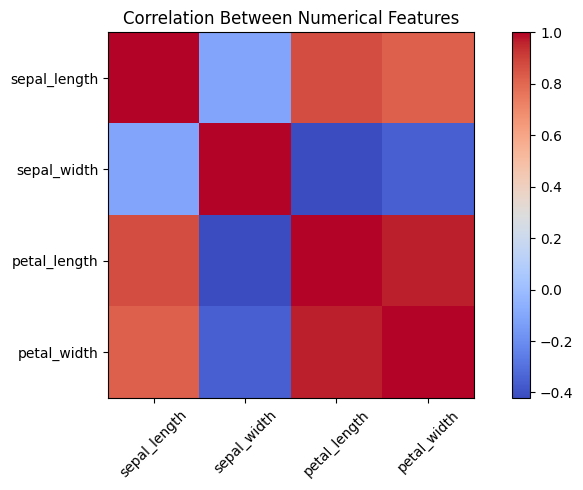

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

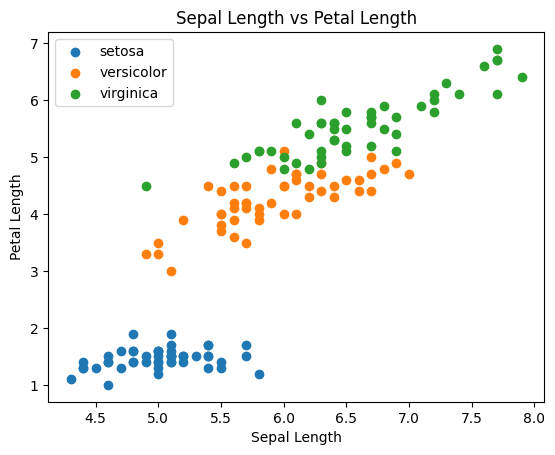

In [ ]:
import matplotlib.pyplot as plt

for species in df["species"].unique():
    subset = df[df["species"] == species]

    plt.scatter(
        subset["sepal_length"],
        subset["petal_length"],
        label=species
   )

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Sepal Length vs Petal Length")
plt.legend()
plt.show()

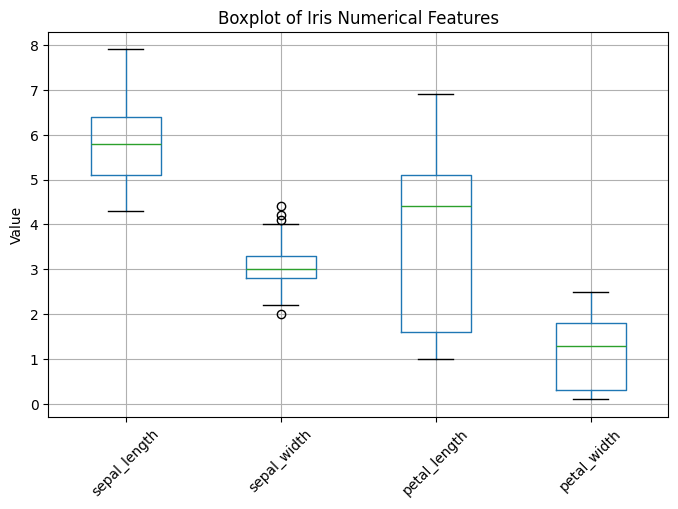

In [ ]:
plt.figure(figsize=(8, 5))
df[numeric_columns].boxplot()
plt.title("Boxplot of Iris Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()